reference code: https://github.com/quadbio/scRNAseq_analysis_python_vignette/blob/main/Tutorial.ipynb and scanpy tutorial

## Import, QC, and Visualize scRNAseq data

In [1]:
import cobra
import matplotlib.pyplot as plt
import GEOparse
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
from scipy import stats
from utils.cfr_suite import apply_cfr 

### Initital dataset loading and QC

In [2]:
gse = GEOparse.get_GEO(geo="GSE208653", destdir="./data")

for k, v in gse.gsms.items():
    print(k, v.metadata)

11-Sep-2026 12:16:49 DEBUG utils - Directory ./data already exists. Skipping.
11-Sep-2026 12:16:49 INFO GEOparse - File already exist: using local version.
11-Sep-2026 12:16:49 INFO GEOparse - Parsing ./data/GSE208653_family.soft.gz: 
11-Sep-2026 12:16:49 DEBUG GEOparse - DATABASE: GeoMiame
11-Sep-2026 12:16:49 DEBUG GEOparse - SERIES: GSE208653
11-Sep-2026 12:16:49 DEBUG GEOparse - PLATFORM: GPL24676
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360680
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360681
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360682
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360683
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360684
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360685
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360686
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360687
11-Sep-2026 12:16:49 DEBUG GEOparse - SAMPLE: GSM6360688


GSM6360680 {'title': ['NO_HPV, replicate 1,scRNAseq'], 'geo_accession': ['GSM6360680'], 'status': ['Public on Apr 02 2023'], 'submission_date': ['Jul 20 2022'], 'last_update_date': ['Apr 02 2023'], 'type': ['SRA'], 'channel_count': ['1'], 'source_name_ch1': ['cervical tissue'], 'organism_ch1': ['Homo sapiens'], 'taxid_ch1': ['9606'], 'characteristics_ch1': ['tissue: cervical tissue', 'cell line: cervical cells', 'cell type: cervical cells', 'disease state: NO_HPV', 'treatment: NO'], 'molecule_ch1': ['total RNA'], 'extract_protocol_ch1': ["Single-cell gel beads in emulsion (GEMs) were generated on a GemCode Single Cell Instrument (10x Genomics). Single-cell RNA-seq cDNA libraries were prepared using Chromium™ Single Cell 3’ V3.1 Reagent Kits (10x Genomics) according to manufacturer's protocol.", 'RNA libraries were generated by 10xGenomics Single Cell 3’ V3.1 Library Gel Bead Kit and prepared for sequencing using standard Illumina protocols'], 'description': ['10X Genomics'], 'data_proc

In [3]:
for gsm_name, gsm in gse.gsms.items():
    print("Name: ", gsm_name)
    print("Metadata:",)
    for key, value in gsm.metadata.items():
        print(" - %s : %s" % (key, ", ".join(value)))
    print ("Table data:",)
    print (gsm.table.head())
    break

Name:  GSM6360680
Metadata:
 - title : NO_HPV, replicate 1,scRNAseq
 - geo_accession : GSM6360680
 - status : Public on Apr 02 2023
 - submission_date : Jul 20 2022
 - last_update_date : Apr 02 2023
 - type : SRA
 - channel_count : 1
 - source_name_ch1 : cervical tissue
 - organism_ch1 : Homo sapiens
 - taxid_ch1 : 9606
 - characteristics_ch1 : tissue: cervical tissue, cell line: cervical cells, cell type: cervical cells, disease state: NO_HPV, treatment: NO
 - molecule_ch1 : total RNA
 - extract_protocol_ch1 : Single-cell gel beads in emulsion (GEMs) were generated on a GemCode Single Cell Instrument (10x Genomics). Single-cell RNA-seq cDNA libraries were prepared using Chromium™ Single Cell 3’ V3.1 Reagent Kits (10x Genomics) according to manufacturer's protocol., RNA libraries were generated by 10xGenomics Single Cell 3’ V3.1 Library Gel Bead Kit and prepared for sequencing using standard Illumina protocols
 - description : 10X Genomics
 - data_processing : Basecalls performed using

In [4]:
for gpl_name, gpl in gse.gpls.items():
    print("Name: ", gpl_name)
    print("Metadata:",)
    for key, value in gpl.metadata.items():
        print(" - %s : %s" % (key, ", ".join(value)))
    print("Table data:",)
    print(gpl.table.head())
    break

Name:  GPL24676
Metadata:
 - title : Illumina NovaSeq 6000 (Homo sapiens)
 - geo_accession : GPL24676
 - status : Public on Mar 02 2018
 - submission_date : Mar 02 2018
 - last_update_date : Nov 05 2018
 - technology : high-throughput sequencing
 - distribution : virtual
 - organism : Homo sapiens
 - taxid : 9606
 - contact_name : ,,GEO
 - contact_country : USA
 - data_row_count : 0
Table data:
Empty DataFrame
Columns: []
Index: []


In [5]:
samples = gse.phenotype_data.index.to_list()
samples

['GSM6360680',
 'GSM6360681',
 'GSM6360682',
 'GSM6360683',
 'GSM6360684',
 'GSM6360685',
 'GSM6360686',
 'GSM6360687',
 'GSM6360688']

In [6]:
for gsm in gse.gsms.values():
    for i in range(1, 4):
        if f'supplementary_file_{i}' in gsm.metadata:
            print(f"Supplementary file {i}: {gsm.metadata[f'supplementary_file_{i}']}")
    url = gsm.metadata[f'supplementary_file_1']
    gsm.download_supplementary_files(directory='./data')

11-Sep-2026 12:16:49 DEBUG utils - Directory /Users/davissineath/Documents/03_Code/Research/UM/oncovirus-hpv/data/Supp_GSM6360680_NO_HPV__replicate_1_scRNAseq already exists. Skipping.
11-Sep-2026 12:16:49 INFO downloader - File /Users/davissineath/Documents/03_Code/Research/UM/oncovirus-hpv/data/Supp_GSM6360680_NO_HPV__replicate_1_scRNAseq/GSM6360680_N_HPV_NEG_1.barcodes.tsv.gz already exist. Use force=True if you would like to overwrite it.
11-Sep-2026 12:16:49 INFO downloader - File /Users/davissineath/Documents/03_Code/Research/UM/oncovirus-hpv/data/Supp_GSM6360680_NO_HPV__replicate_1_scRNAseq/GSM6360680_N_HPV_NEG_1.features.tsv.gz already exist. Use force=True if you would like to overwrite it.
11-Sep-2026 12:16:49 INFO downloader - File /Users/davissineath/Documents/03_Code/Research/UM/oncovirus-hpv/data/Supp_GSM6360680_NO_HPV__replicate_1_scRNAseq/GSM6360680_N_HPV_NEG_1.matrix.mtx.gz already exist. Use force=True if you would like to overwrite it.
11-Sep-2026 12:16:49 ERROR GEOT

Supplementary file 1: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360680/suppl/GSM6360680_N_HPV_NEG_1.barcodes.tsv.gz']
Supplementary file 2: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360680/suppl/GSM6360680_N_HPV_NEG_1.features.tsv.gz']
Supplementary file 3: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360680/suppl/GSM6360680_N_HPV_NEG_1.matrix.mtx.gz']
Supplementary file 1: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360681/suppl/GSM6360681_N_HPV_NEG_2.barcodes.tsv.gz']
Supplementary file 2: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360681/suppl/GSM6360681_N_HPV_NEG_2.features.tsv.gz']
Supplementary file 3: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360681/suppl/GSM6360681_N_HPV_NEG_2.matrix.mtx.gz']
Supplementary file 1: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360682/suppl/GSM6360682_N_1.barcodes.tsv.gz']
Supplementary file 2: ['ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6360nnn/GSM6360682/sup

In [7]:
adatas = {}
samples = ['NO_HPV_r1', 
            'NO_HPV_r2',
            'N_HPV_r1',
            'N_HPV_r2',
            'HSIL_HPV_r1',
            'HSIL_HPV_r2',
            'CA_HPV_r1',
            'CA_HPV_r2',
            'CA_HPV_r3']
            
folders = ['Supp_GSM6360680_NO_HPV__replicate_1_scRNAseq',
         'Supp_GSM6360681_NO_HPV__replicate_2_scRNAseq',
         'Supp_GSM6360682_N_HPV__replicate_1_scRNAseq',
         'Supp_GSM6360683_N_HPV__replicate_2_scRNAseq',
         'Supp_GSM6360684_HSIL_HPV__replicate_1_scRNAseq',
         'Supp_GSM6360685_HSIL_HPV__replicate_2_scRNAseq',
         'Supp_GSM6360686_CA_HPV__replicate_1_scRNAseq',
         'Supp_GSM6360687_CA_HPV__replicate_2_scRNAseq',
         'Supp_GSM6360688_CA_HPV__replicate_3_scRNAseq']

prefixes = ['GSM6360680_N_HPV_NEG_1.',
            'GSM6360681_N_HPV_NEG_2.',
            'GSM6360682_N_1.',
            'GSM6360683_N_2.',
            'GSM6360684_HSIL_1.',
            'GSM6360685_HSIL_2.',
            'GSM6360686_SCC_4.',
            'GSM6360687_SCC_5.',
            'GSM6360688_ADC_6.']

for s, f, p in zip(samples,folders, prefixes):   
    sample_adata = sc.read_10x_mtx(f"./data/{f}",
                                   prefix=p,
                                #    var_names="gene_symbols",
                                   )

    print(f"Loaded state: {s}")
    print(sample_adata)

    sample_adata.obs_names_make_unique()
    sample_adata.var_names_make_unique()


    sample_adata.var["mt"] = sample_adata.var_names.str.startswith("MT-")

    sc.pp.calculate_qc_metrics(sample_adata, qc_vars=["mt"], inplace=True)

    sample_adata = sample_adata[(sample_adata.obs["pct_counts_mt"] < 20) &
                                (sample_adata.obs["total_counts"] > 200) & 
                                (sample_adata.obs["total_counts"] < 50000)
                                ].copy()
    
    print(f"After QC: {s}")
    print(sample_adata)

    sc.pp.filter_genes(sample_adata, min_cells=3)

    print(f"After gene filtering: {s}")
    print(sample_adata)

    adatas[s] = sample_adata

Loaded state: NO_HPV_r1
AnnData object with n_obs × n_vars = 11619 × 20615
    var: 'gene_ids', 'feature_types'
    layers: None (.X)
After QC: NO_HPV_r1
AnnData object with n_obs × n_vars = 10236 × 20615
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: None (.X)
After gene filtering: NO_HPV_r1
AnnData object with n_obs × n_vars = 10236 × 16989
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total

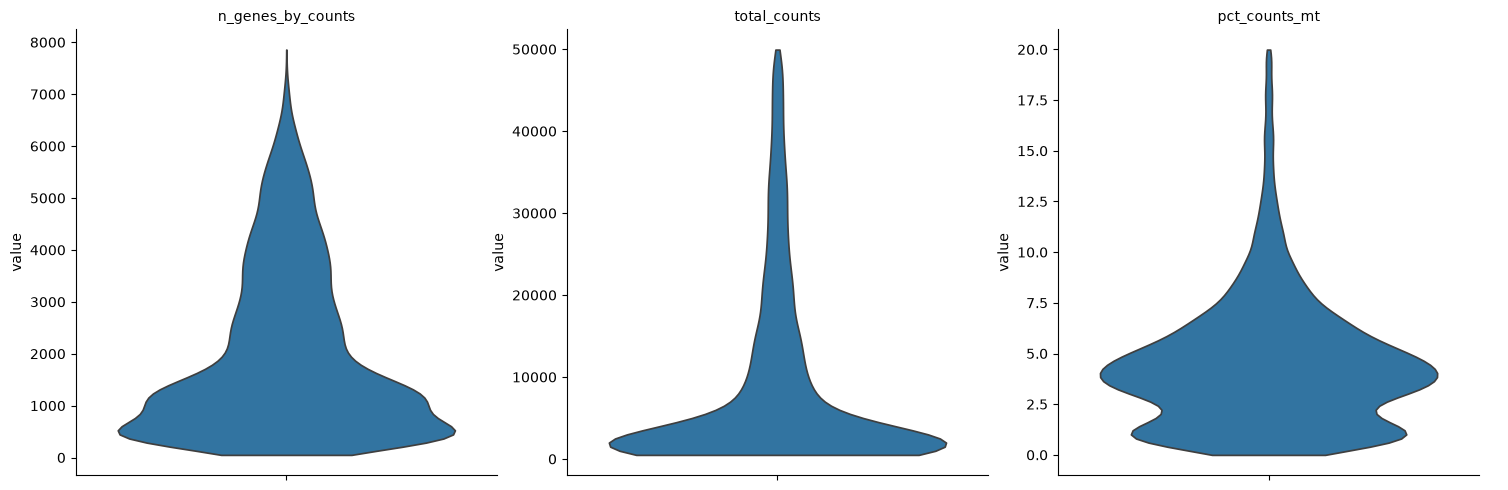

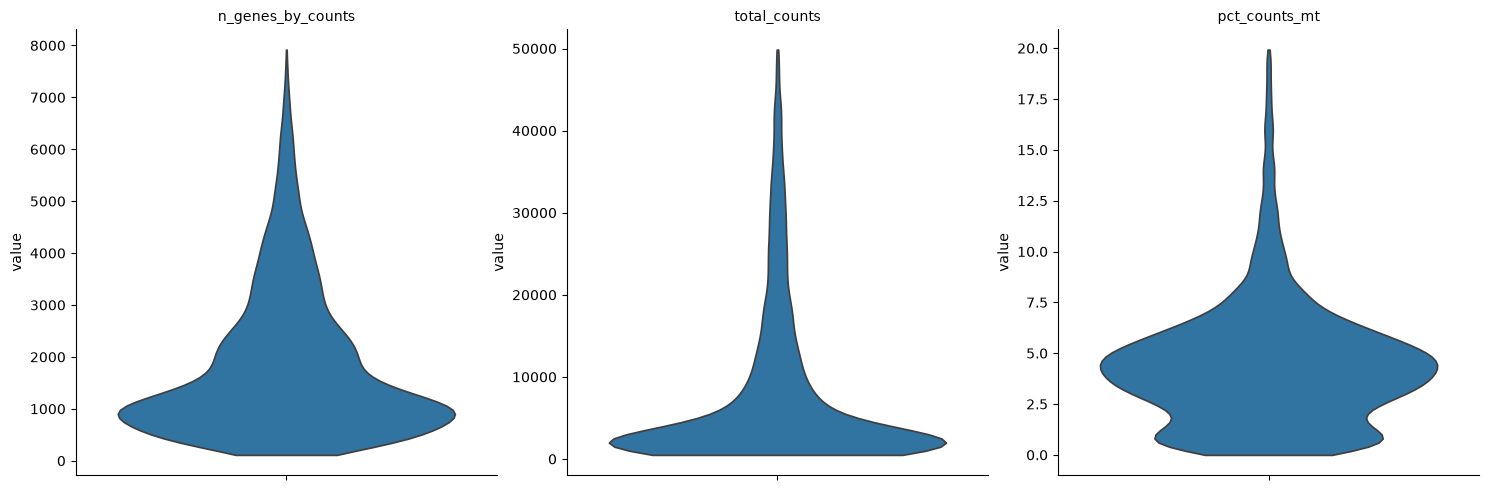

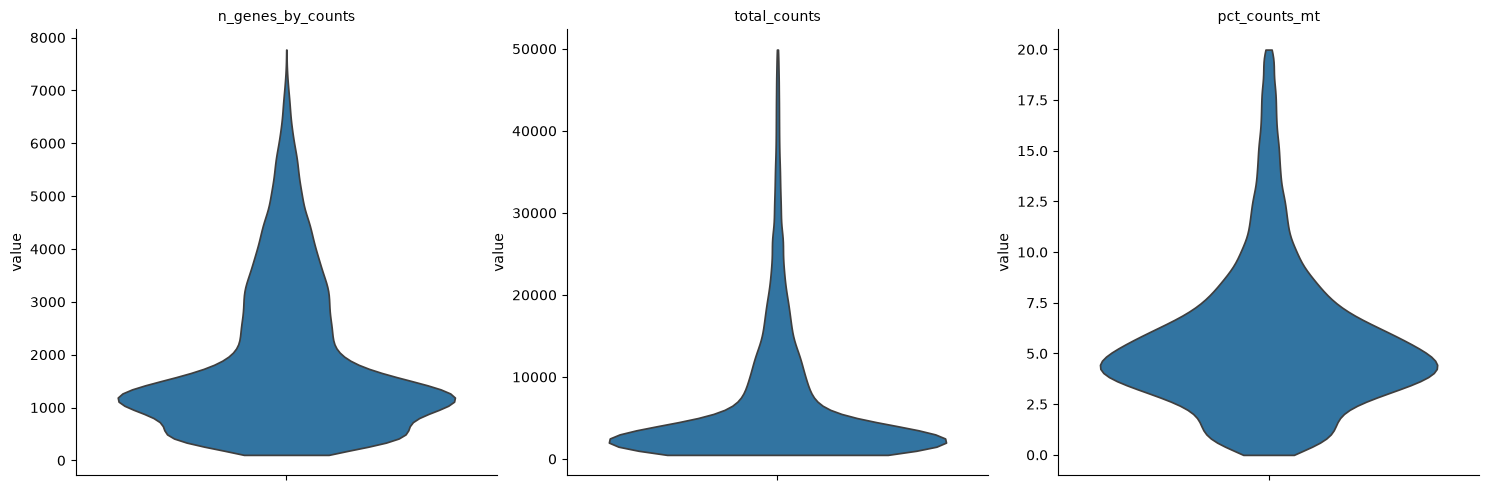

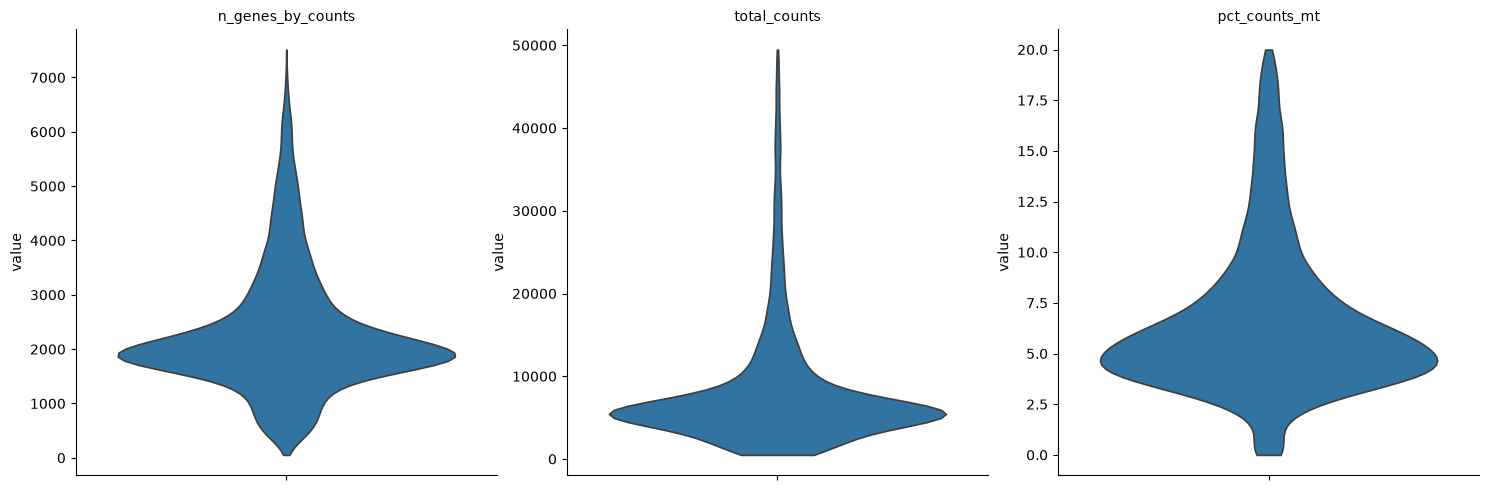

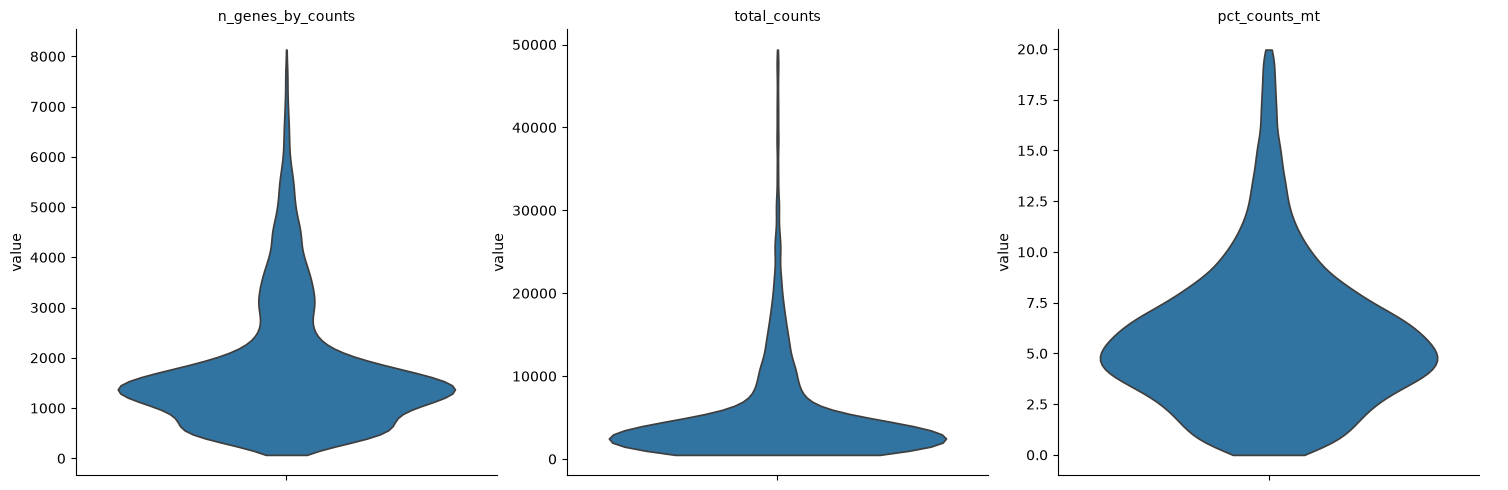

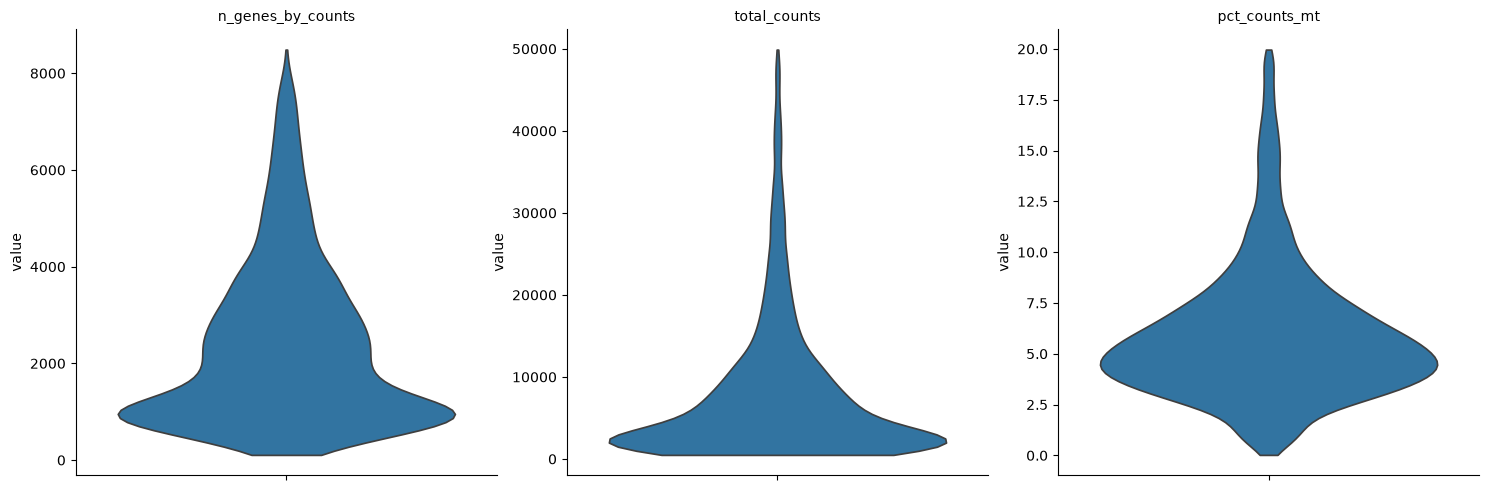

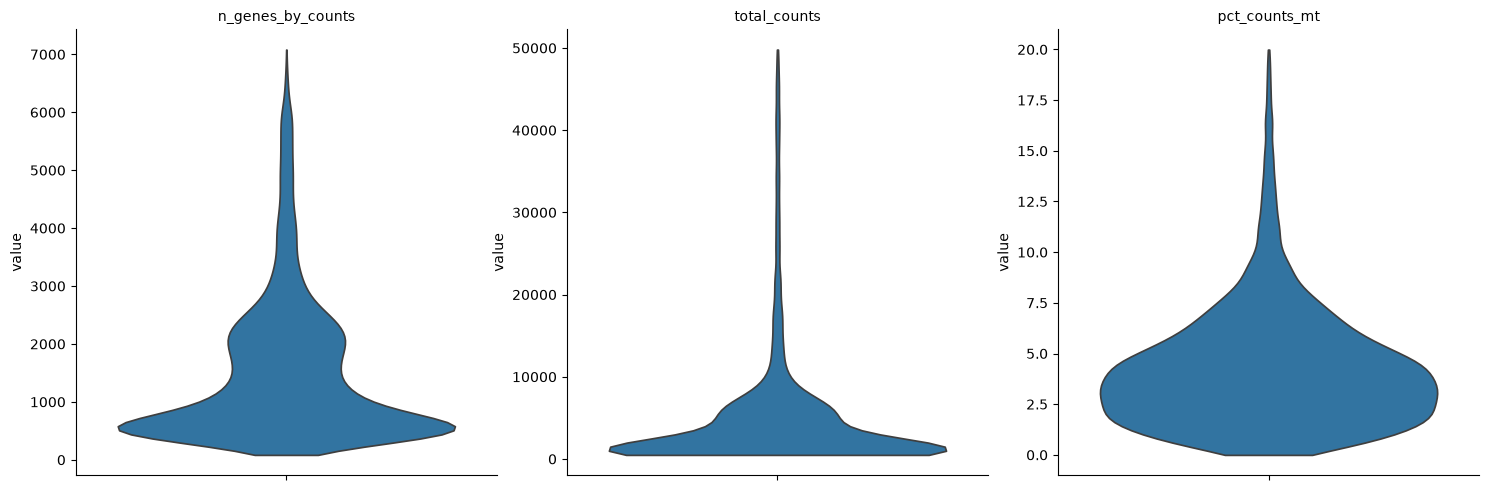

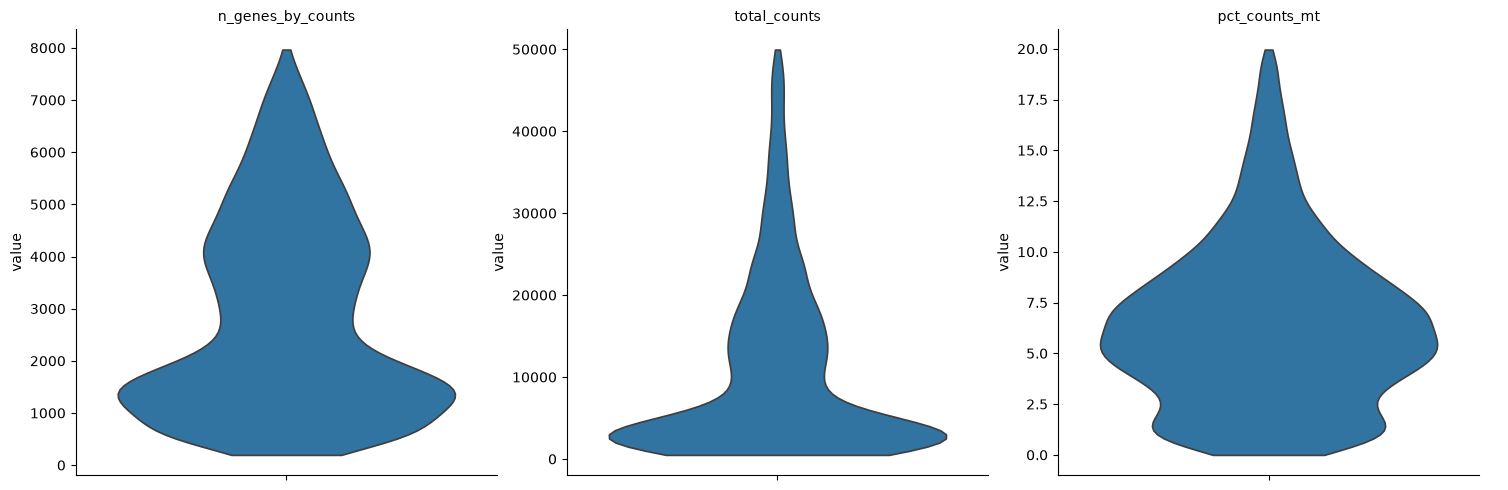

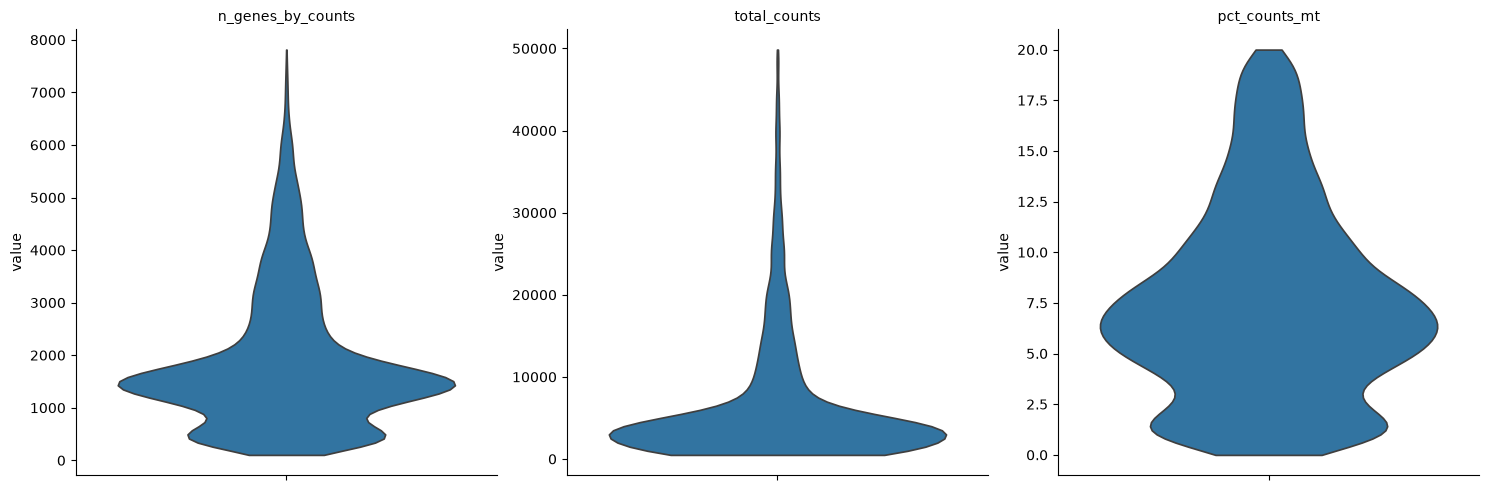

In [8]:
for s in samples: 
    sc.pl.violin(adatas[s], ["n_genes_by_counts", "total_counts", "pct_counts_mt"], size=0, multi_panel=True)

In [9]:
adata = ad.concat(adatas, label="timepoint", join="outer", index_unique="-")

sc.pp.scrublet(adata, batch_key="timepoint")
# adata.obs_names_make_unique()

print("\nCells after combining samples:")
print(adata.obs["timepoint"].value_counts())

print("\nFinal AnnData:")
print(adata)


Cells after combining samples:
timepoint
N_HPV_r1       15214
NO_HPV_r1      10236
NO_HPV_r2       8539
CA_HPV_r1       8538
CA_HPV_r3       8269
HSIL_HPV_r2     6903
N_HPV_r2        6732
HSIL_HPV_r1     5945
CA_HPV_r2       5922
Name: count, dtype: int64

Final AnnData:
AnnData object with n_obs × n_vars = 76298 × 18129
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'timepoint', 'n_genes', 'doublet_score', 'predicted_doublet'
    uns: 'scrublet'
    layers: None (.X)


In [10]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
adata.layers["normalized_total"] = adata.X.copy()

adata.X.data = np.log2(adata.X.data + 1)
adata.layers["log2"] = adata.X.copy()

adata.X = adata.layers["normalized_total"]
adata.X = sc.pp.log1p(adata.X)

### load from here after initial run

In [11]:
adata.write_h5ad("./data/processed_data.h5ad")
# adata = sc.read_h5ad("./data/processed_TX1241.h5ad")

Here I could regress out cell cycle but do not currently

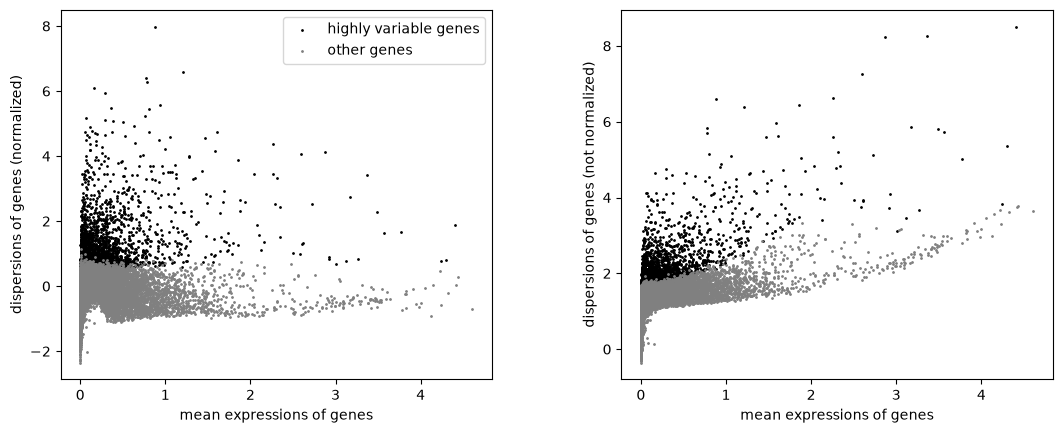

In [12]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="timepoint")
sc.pl.highly_variable_genes(adata)

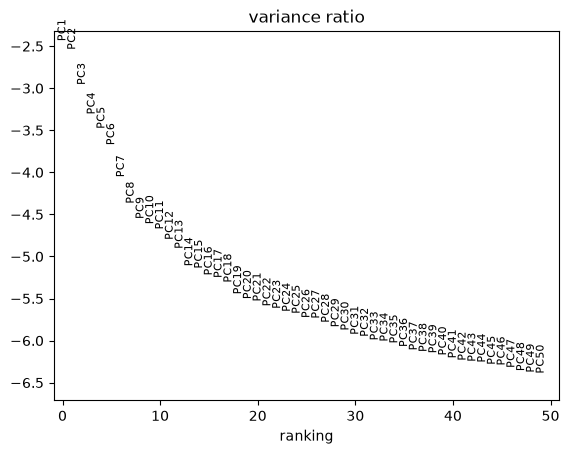

In [13]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

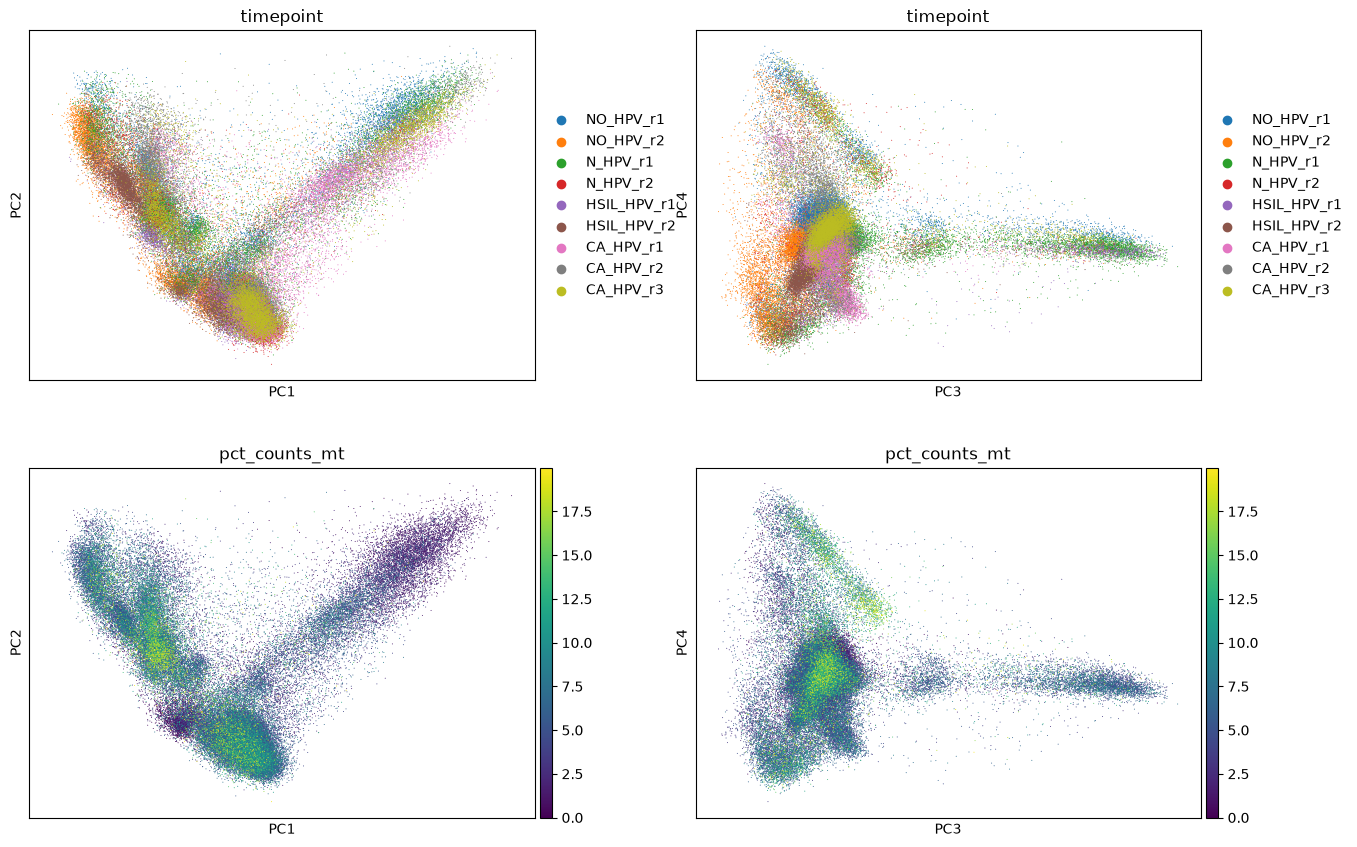

In [14]:
sc.pl.pca(
    adata,
    color=["timepoint", "timepoint", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    wspace=0.2,
    size=2,
)

/opt/anaconda3/envs/oncovirus/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


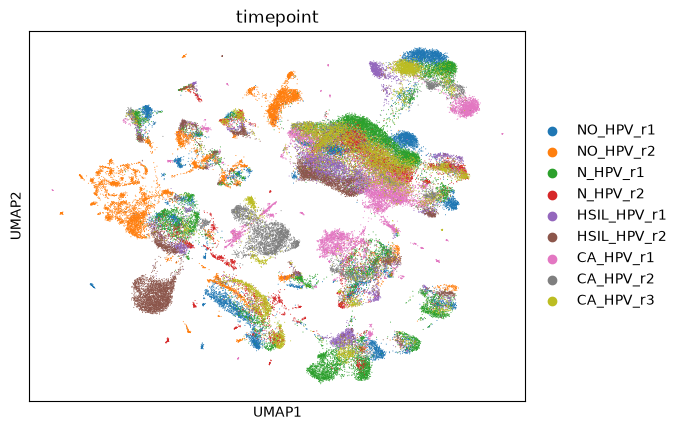

In [15]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="timepoint",
    size=2,
)

In [26]:
sc.tl.leiden(adata, resolution=0.1, key_added='leiden_res_0.1')
sc.tl.leiden(adata, resolution=0.2, key_added='leiden_res_0.2')
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_res_0.5')
# sc.tl.leiden(adata, resolution=1, key_added='leiden_res_1')

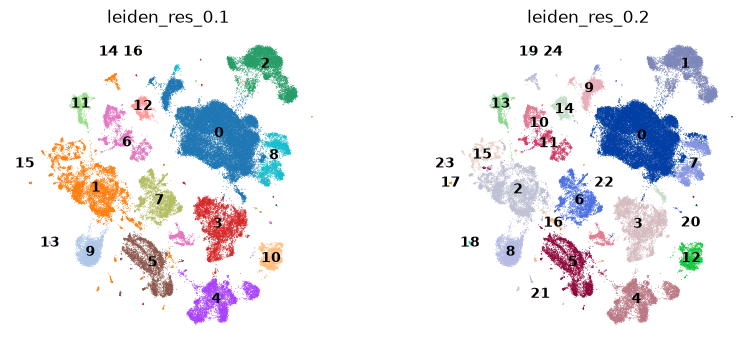

In [27]:
with plt.rc_context({'figure.figsize':(4,4)}):
    sc.pl.umap(adata, color=['leiden_res_0.1','leiden_res_0.2'], frameon=False, legend_loc='on data')

In [28]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    # "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": ["MS4A1", "ITGB1", "COL4A4", "PRDM1", "IRF4", "PAX5", "BCL11A", "BLK", "IGHD", "IGHM"],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

In [29]:
def group_max(adata: sc.AnnData, groupby: str) -> str:
    import pandas as pd

    agg = sc.get.aggregate(adata, by=groupby, func="mean")
    return pd.Series(agg.layers["mean"].sum(1), agg.obs[groupby]).idxmax()

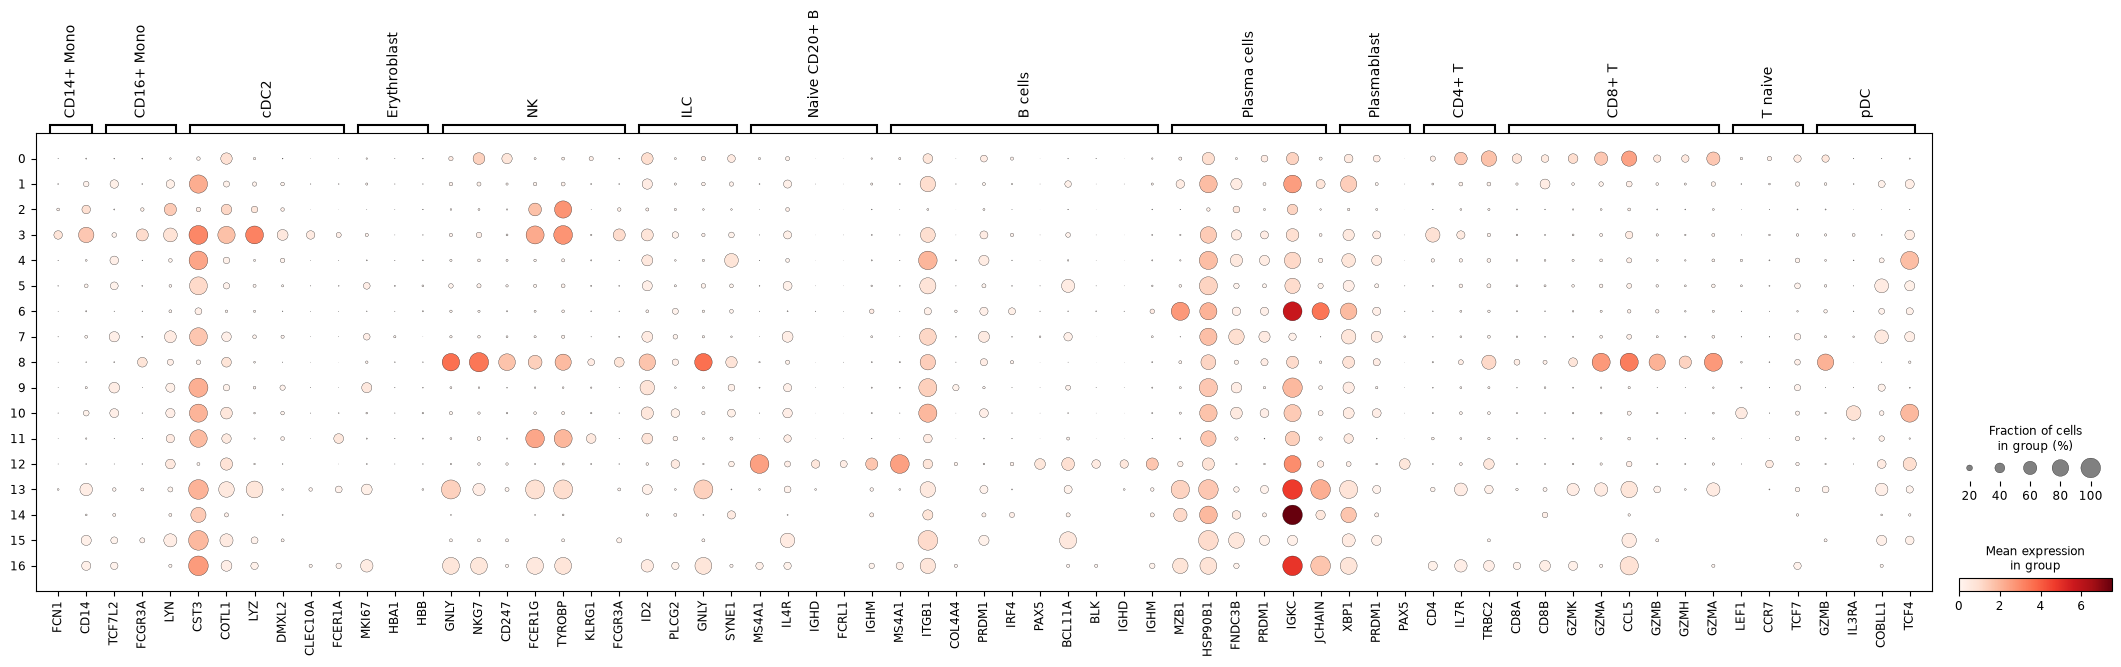

In [30]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.1")

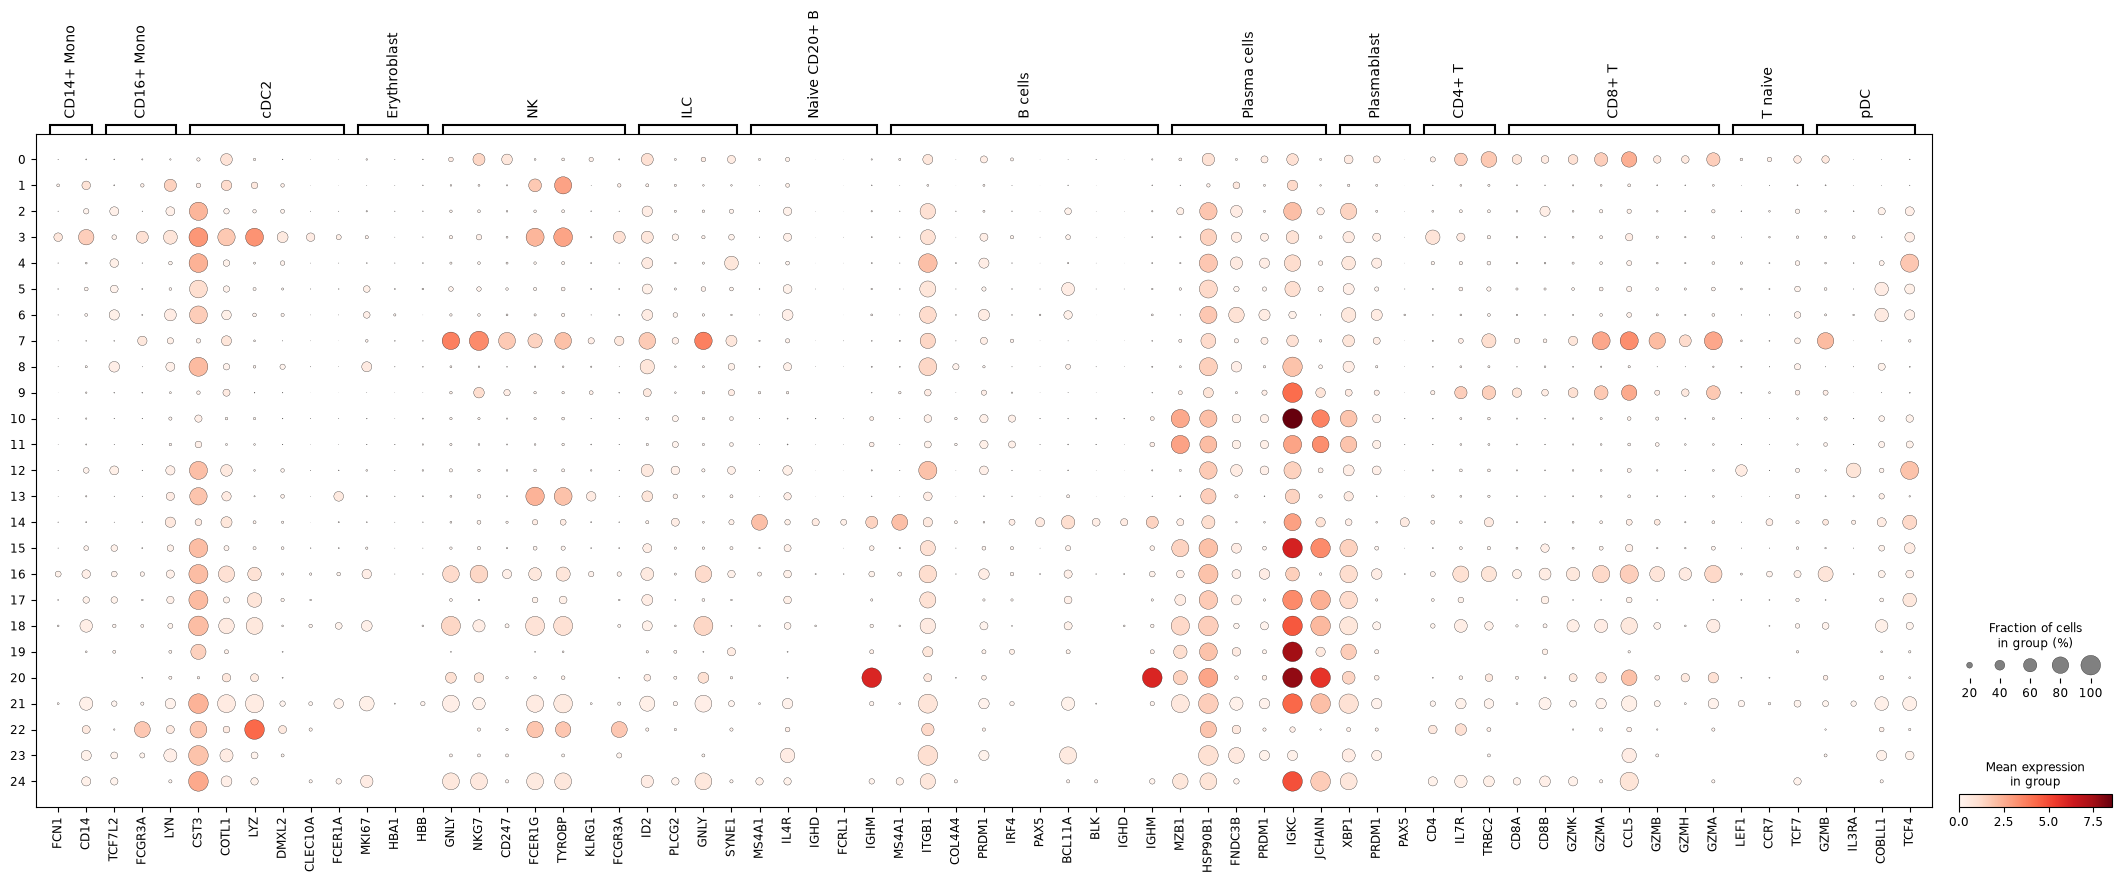

In [31]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res_0.2")

In [32]:
import celltypist as ct

In [33]:
ct.models.download_models(model=["Immune_All_Low.pkl"], force_update=True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /Users/davissineath/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl


In [34]:
model = ct.models.Model.load(model="Immune_All_Low.pkl")
predictions = ct.annotate(adata, model="Immune_All_Low.pkl", majority_voting=True, over_clustering="leiden_res_0.5")
# convert back to anndata||
adata = predictions.to_adata()

🔬 Input data has 76298 cells and 18129 genes
🔗 Matching reference genes in the model
🧬 5514 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


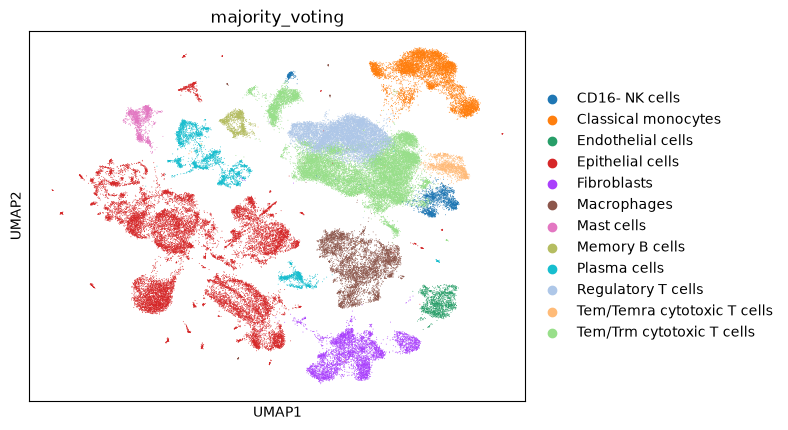

In [35]:
sc.pl.umap(adata, color="majority_voting", ncols=1)

In [ ]:
cell_counts = pd.DataFrame()
for s in samples:
    cell_counts[s] = adata.obs["majority_voting"].filter(like=s).value_counts()
cell_counts = cell_counts.T

cell_counts

majority_voting,Tem/Trm cytotoxic T cells,Epithelial cells,Classical monocytes,Fibroblasts,Macrophages,Plasma cells,CD16- NK cells,Mast cells,Endothelial cells,Memory B cells,Regulatory T cells,Tem/Temra cytotoxic T cells
NO_HPV_r1,2598,2276,1897,718,678,595,463,445,316,125,72,53
NO_HPV_r2,2112,4129,5,100,260,1507,186,100,105,35,0,0
N_HPV_r1,2355,1920,1471,2637,907,645,299,440,663,82,3724,71
N_HPV_r2,1788,1602,59,171,450,15,39,30,18,280,1714,566
HSIL_HPV_r1,2675,564,738,698,332,174,175,85,72,143,63,226
HSIL_HPV_r2,1724,3678,30,96,272,380,192,118,168,217,3,25
CA_HPV_r1,3558,667,1285,123,1780,233,70,29,22,32,700,39
CA_HPV_r2,519,2694,545,110,482,37,237,147,13,10,1028,100
CA_HPV_r3,1620,1632,1406,348,313,58,89,54,104,229,2007,409


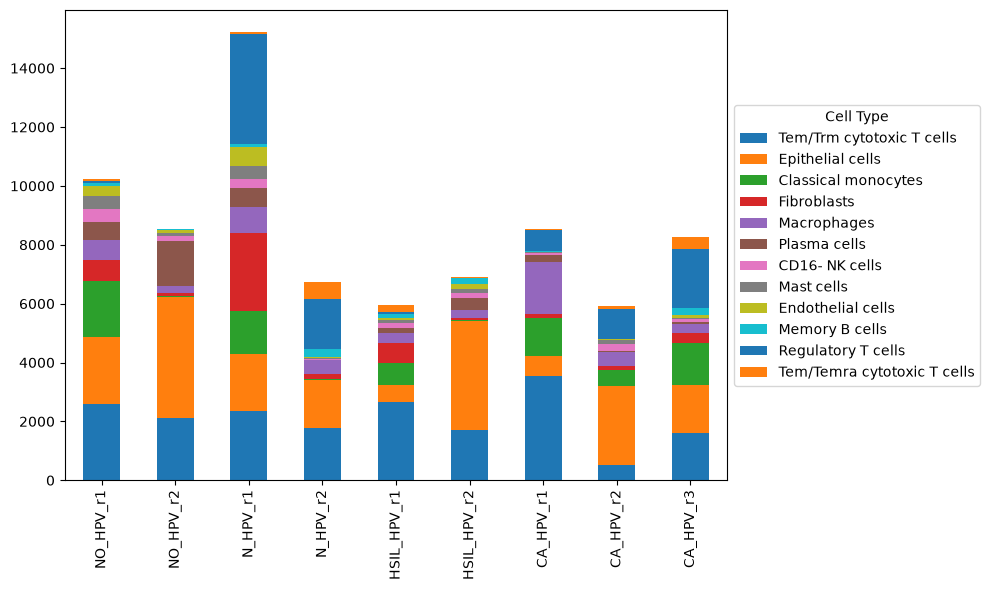

In [54]:
cell_counts.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='Cell Type')
plt.tight_layout()
plt.show()

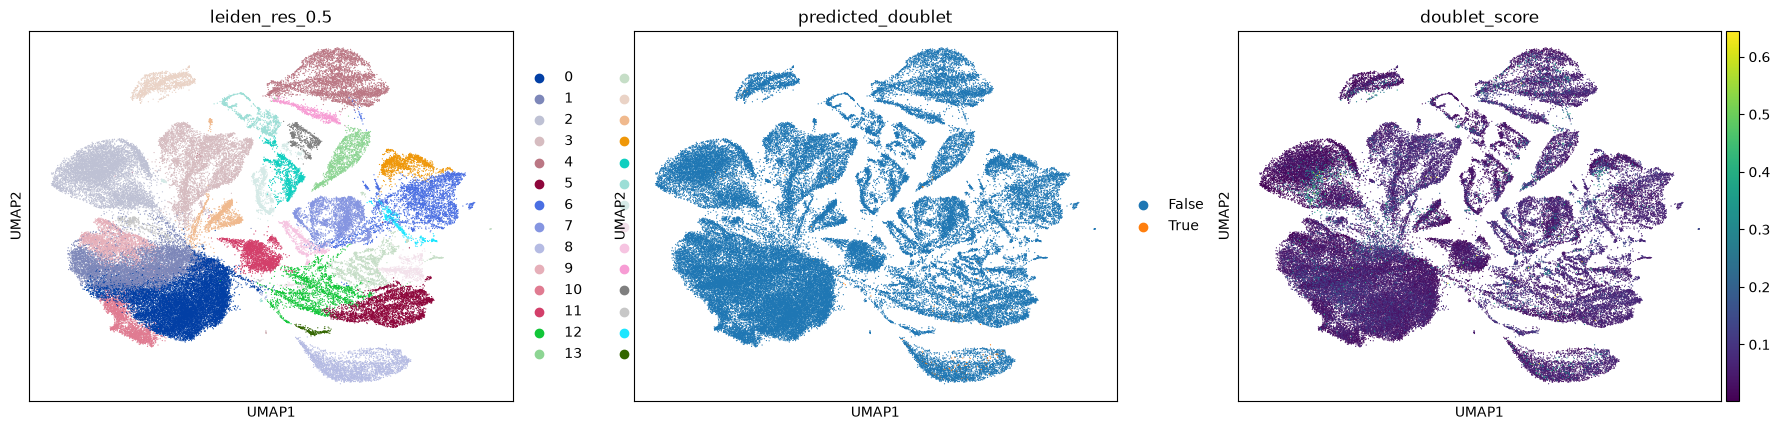

In [18]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.5", "predicted_doublet", "doublet_score"],
    # wspace=0.5,
    size=3,
)

- the total counts per cell (UR)
- the percentage of counts in mitochondrial genes (LL)
- the number of genes expressed in the count matrix (LR)

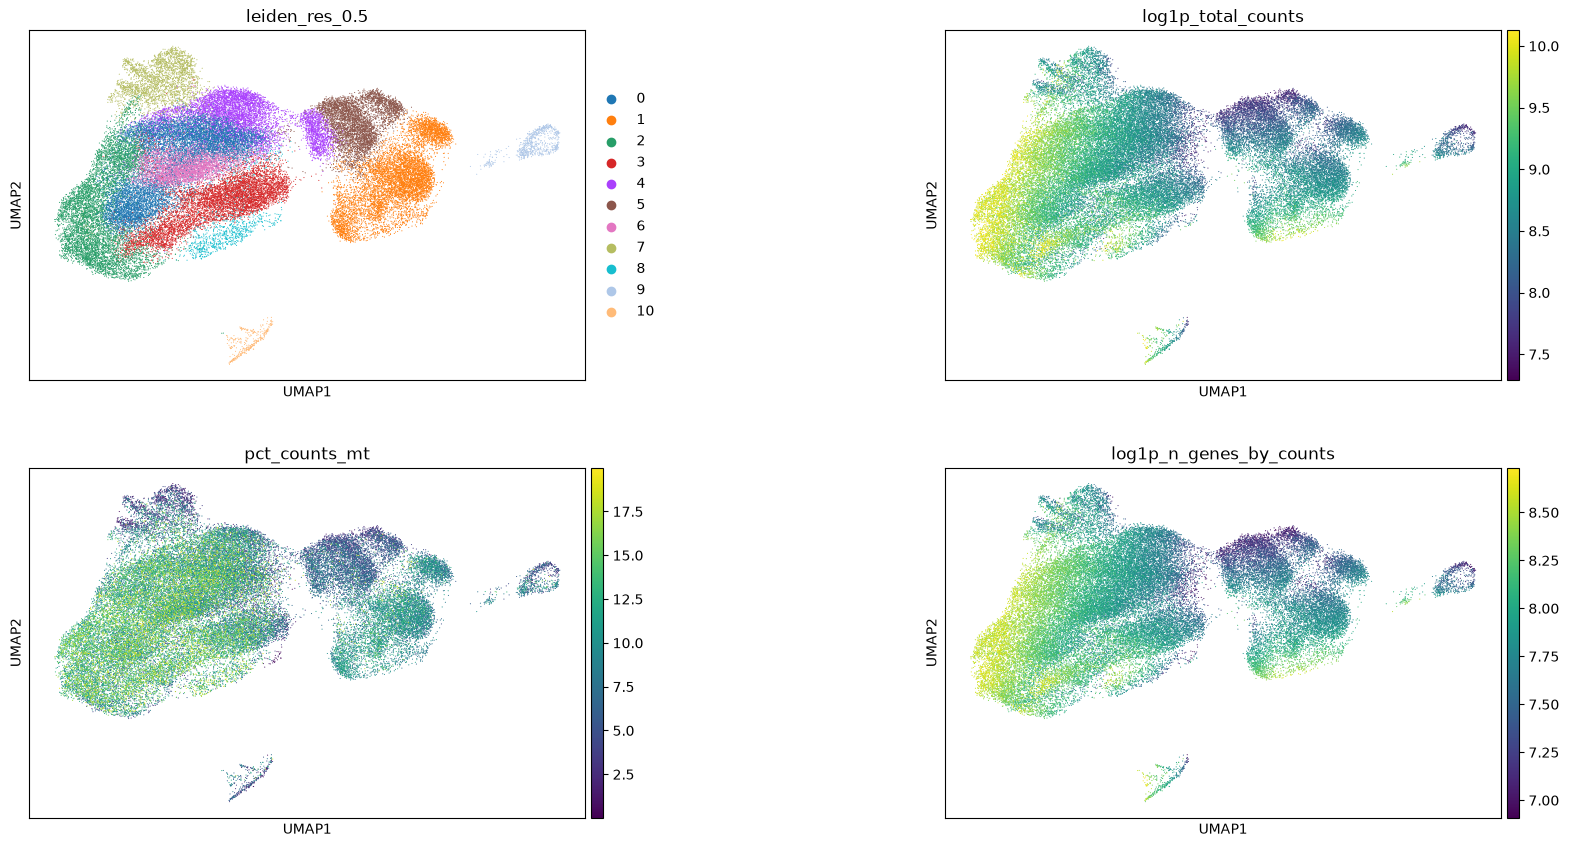

In [11]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.5", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

## Begin Assessing Metabolic Genes Seperately

In [12]:
data_genes = adata.var_names.to_list()
data_genes = [g.split(".")[0] for g in data_genes]
# data_genes

In [13]:
model = cobra.io.read_sbml_model("gems/Recon3D.xml")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2861474
Academic license 2861474 - for non-commercial use only - registered to ws___@umich.edu


In [14]:
gene_map = pd.read_excel("gene_id_map_recon3d.xlsx", header=1, index_col=0).fillna("")
model_genes = [gene.id for gene in model.genes]

In [15]:
# Can clean into function later
model_gene_HGNC_map = {}
for g in model_genes:
    gid = g.split("_")[0]
    if int(gid) in gene_map.index:
        gsym = gene_map.loc[int(gid), "HGNC symbol"]
        model_gene_HGNC_map[g] = gsym
model_gene_HGNC_map = pd.DataFrame.from_dict(model_gene_HGNC_map, orient="index", columns=["HGNC symbol"])
# model_gene_HGNC_map

In [16]:
subsystem_genes = {}
for rxn in model.reactions:
    sub = rxn.subsystem
    genes = [g.id for g in rxn.genes]

    if len(genes) > 0:
        if sub not in subsystem_genes:
            subsystem_genes[sub] = set()
        for g in genes:
            subsystem_genes[sub].add(g)
        
# subsystem_genes"

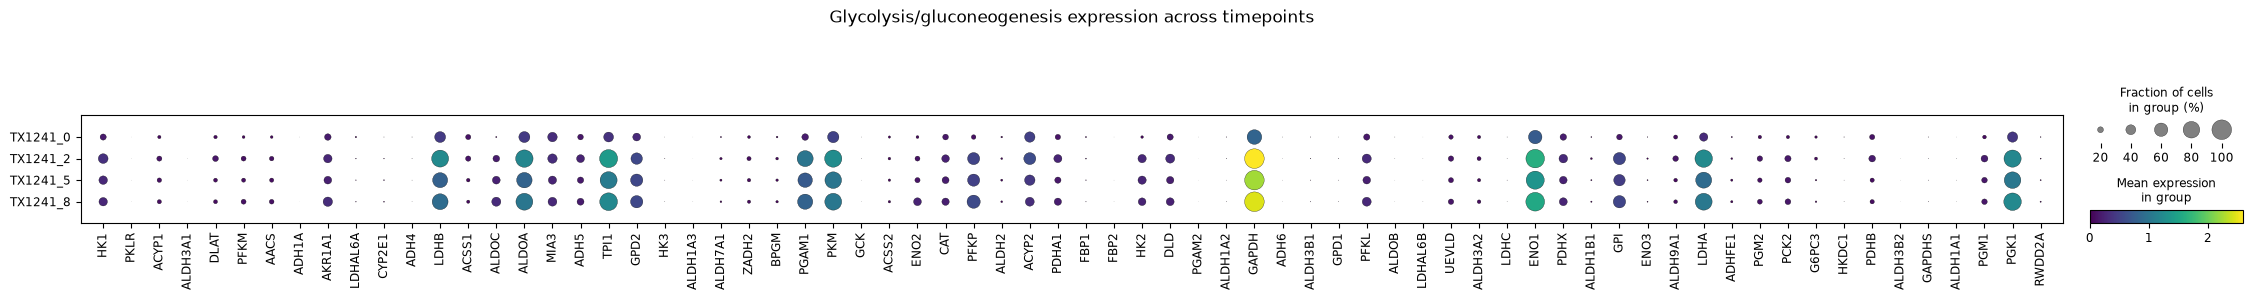

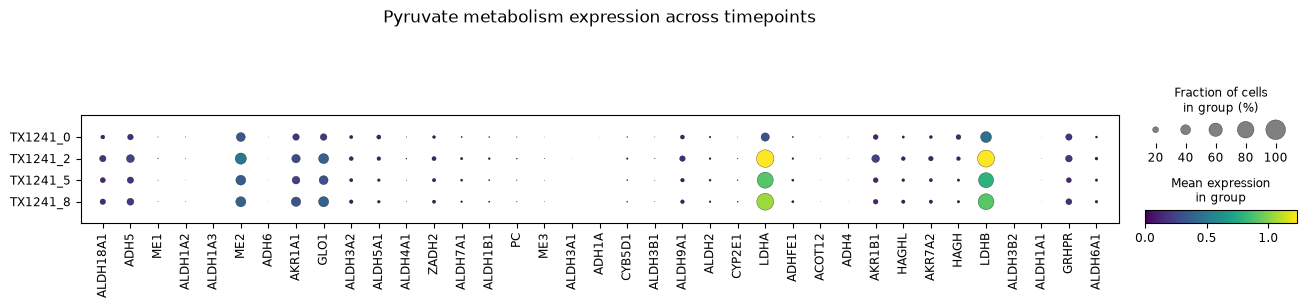

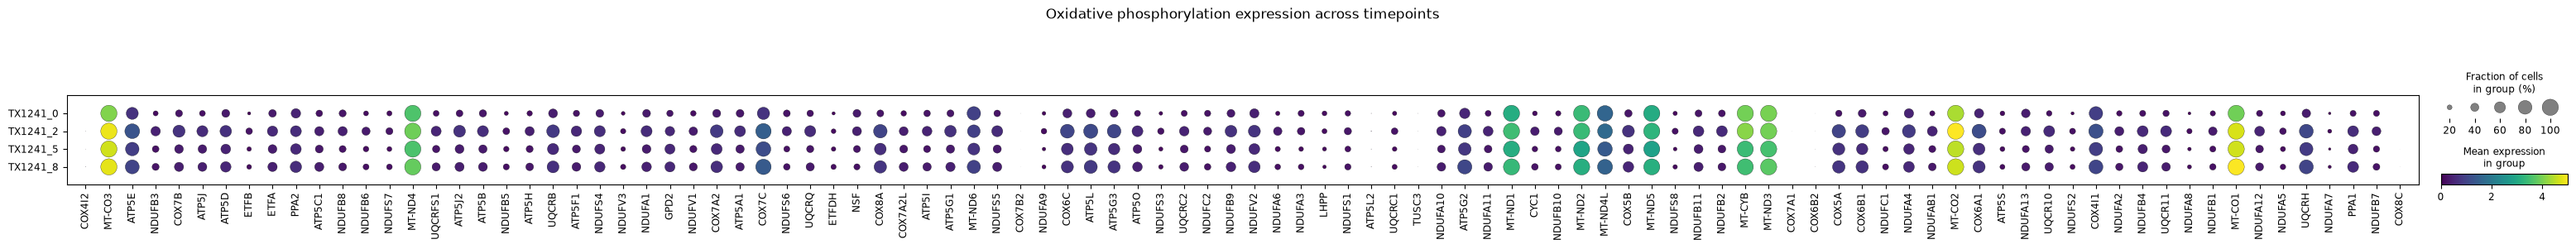

In [17]:
selected_subs = ["Glycolysis/gluconeogenesis",
                 "Pyruvate metabolism",
                 "Oxidative phosphorylation"]

for s in selected_subs:
    gids = subsystem_genes[s]
    sub_genes = (pd.Index(gids).map(model_gene_HGNC_map["HGNC symbol"]))

    sub_genes = (sub_genes[sub_genes.isin(set(data_genes))].unique().tolist())

    sc.pl.dotplot(
        adata,
        var_names=sub_genes,
        groupby="timepoint",
        expression_cutoff=0,
        use_raw=False,       
        standard_scale=None,  
        cmap="viridis",
        dot_min=0,
        dot_max=1,
        title=f'{s} expression across timepoints',
        # save="_timepoints.png",
    )

In [18]:
print(len(model_gene_HGNC_map))
print(len(model_genes))
print(set(model_genes) - set(model_gene_HGNC_map.index.to_list()))

2243
2248
{'200931_AT1', '5446_AT1', '123264_AT1', '0', '8041_AT1'}


Show which model genes not in data

In [19]:
missing_genes = set(model_gene_HGNC_map["HGNC symbol"].to_list()) - set(data_genes)
mapped_genes = set(model_gene_HGNC_map["HGNC symbol"].to_list()).intersection(set(data_genes))
print(len(missing_genes))
print(len(mapped_genes))
print(missing_genes)

131
1745
{'', 'ADH1C', 'UGT1A7', 'ENTPD8', 'PLPPR5', 'AADAT', 'SLC6A14', 'SLC2A10', 'CYP2A13', 'UGT2A1', 'UGT1A9', 'SLC6A10P', 'PLA2G2A', 'GSTM1', 'HAO2', 'MTHFD2P1', 'GGTLC1', 'GK2', 'FTMT', 'PPAP2C', 'SLC34A3', 'CLPS', 'AGXT', 'GGTLC2', 'PRPS1L1', 'TPSAB1', 'SLC17A2', 'CH25H', 'CHST5', 'HYALP1', 'UGT1A4', 'TH', 'ALPP', 'AQP4', 'PPAP2B', 'SLCO1B3', 'AKR1B10', 'SLC17A6', 'PNLIPRP2', 'ADH7', 'TPSD1', 'HS3ST6', 'SOD3', 'UROC1', 'PGK2', 'FABP9', 'UGT1A10', 'HSD3B1', 'SLC6A5', 'NOS2P1', 'UGT1A5', 'GK3P', 'TKTL2', 'GPX5', 'TPI1P2', 'HSD3B2', 'ELOVL3', 'B3GNT1', 'OTC', 'PDHA2', 'CYP2A7', 'CHST1', 'AQP5', 'CYP7A1', 'G6PC', 'FABP1', 'ALPI', 'SLC18A3', 'GPX6', 'UGT1A3', 'G6PC2', 'LALBA', 'CPA1', 'UGT2B10', 'CLC', 'GPX8', 'PSPHP1', 'HSD17B7P2', 'ALPPL2', 'CYP11B2', 'GCNT6', 'PLA2G3', 'CYP21A2', 'LDHD', 'AQP2', 'PLPPR4', 'B3GALT1', 'SLC17A4', 'AKR1C8P', 'CYP2C18', 'CYP11B1', 'PLA2G2E', 'TYRP1', 'SLC52A3', 'LOC286297', 'LOC102724197', 'FABP7', 'CYP2C19', 'LGALS13', 'ATP1B4', 'SLC1A7', 'AGPAT6', 'C

In [20]:
log2_df = adata[:, list(mapped_genes)].to_df(layer="log2").T
# log2_df

In [21]:
metabolic_z_score = pd.DataFrame(stats.zscore(log2_df, axis=1), index=log2_df.index, columns=log2_df.columns)
# metabolic_z_score